# Paper 1- Fake News Classification Using LSTM-Based Deep Learning Models


*Paper:* Halyna Padalko, Vasyl Chomko, Dmytro Chumachenko

*Dataset:* [Fake News Detection Kaggle](https://www.kaggle.com/datasets/emineyetm/fake-news-detection)

*Architecture:* BiLSTM with Attention Mechanism

In [1]:
import pandas as pd
import numpy as np
import re
import string
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Create a folder in Drive for our project
SAVE_PATH = '/content/drive/MyDrive/Project_DL_BiLSTM/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f" Save path ready: {SAVE_PATH}")

Mounted at /content/drive
 Save path ready: /content/drive/MyDrive/Project_DL_BiLSTM/


In [3]:
import pandas as pd
import numpy as np

fake_db= pd.read_csv('/content/drive/MyDrive/Project_DL_BiLSTM/Fake.csv')
true_db= pd.read_csv('/content/drive/MyDrive/Project_DL_BiLSTM/True.csv')

# add lebels
fake_db['label']=1
true_db['label']=0

# combine
df=pd.concat([fake_db,true_db], ignore_index=True)



In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel Distribution:\n", df['label'].value_counts())
print("\nSample rows:\n", df.head(3))
print("\nNull values:\n", df.isnull().sum())

Shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

Label Distribution:
 label
1    23481
0    21417
Name: count, dtype: int64

Sample rows:
                                                title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   

                date  label  
0  December 31, 2017      1  
1  December 31, 2017      1  
2  December 30, 2017      1  

Null values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [5]:
# My data summary
"""
44,898 rows and 5 columns (title, text, subject, date, label)
No null values — clean dataset, no missing data to handle
Label distribution: 23,481 Fake vs 21,417 Real

"""

'\n44,898 rows and 5 columns (title, text, subject, date, label)\nNo null values — clean dataset, no missing data to handle\nLabel distribution: 23,481 Fake vs 21,417 Real\n\n'

In [6]:
# Hyperparameters
MAX_VOCAB = 50000
MAX_LEN   = 500
EMBED_DIM = 64
LSTM_UNITS = 20
DENSE_UNITS = 17

# Combine title + text
df['content'] = df['title'] + ' ' + df['text']

# Clean text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = df['content'].apply(clean_text)

# """
# These numbers are:

# Highly specific → "911" in one article means something different than "911" in another
# Not generalizable → the model memorizes specific numbers instead of learning language patterns
# Too sparse → each number appears very rarely, so the model can't learn anything meaningful from them

# We want the model to learn language patterns, not memorize specific figures.

# """

# Tokenization
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['content'])
sequences = tokenizer.texts_to_sequences(df['content'])

# Padding
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

# Neural networks require all inputs to be the same shape. Now every article is the same length (MAX_LEN=300) and can be processed in batches efficiently.

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Vocabulary size:", len(tokenizer.word_index))



X_train shape: (35918, 500)
X_test shape:  (8980, 500)
Vocabulary size: 226543


# Model 1 --> Building the BiLSTM Model

In [8]:
from tensorflow.keras.regularizers import l2

def build_bilstm():
    inputs = Input(shape=(MAX_LEN,))

    x = Embedding(MAX_VOCAB, EMBED_DIM,
                  trainable=False)(inputs)        # ← freeze embedding!

    x = Bidirectional(LSTM(LSTM_UNITS * 2,
                           kernel_regularizer=l2(0.01),
                           return_sequences=True))(x)
    x = Dropout(0.5)(x)

    x = Bidirectional(LSTM(LSTM_UNITS,
                           kernel_regularizer=l2(0.01)))(x)
    x = Dropout(0.5)(x)

    x = Dense(DENSE_UNITS, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

bilstm_model = build_bilstm()

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.0001),         # ← slower learning rate!
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 500, 64)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500, 80)        │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 40)             │        16,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 17)             │           697 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,250,475 (12.40 MB)

 Trainable params: 50,475 (197.17 KB)

 Non-trainable params: 3,200,000 (12.21 MB)

  * Input → takes padded sequences of length 500
  * Embedding → converts each integer (word ID) into a 128-dim dense vector —     the model learns these vectors during training
  * BiLSTM Layer 1 → reads text forward + backward, returns sequences for every timestep
  * Dropout → randomly turns off 30% of neurons during training to prevent overfitting
  * BiLSTM Layer 2 → reads the output of Layer 1, returns only the final hidden state
  * Dense → learns higher-level patterns from LSTM output
  * Dense(1, sigmoid) → outputs a probability between 0 and 1 (fake or real)




In [9]:
# training model

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,                    # ← reduced from 3 to 1!
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}bilstm_best.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(     # ← NEW callback!
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=0.000001,
    verbose=1
)

history_bilstm = bilstm_model.fit(
    X_train, y_train,
    epochs=10,                     # ← increase epochs (early stop handles it)
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint, reduce_lr],  # ← add reduce_lr!
    verbose=1
)

Epoch 1/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5330 - loss: 3.5151
Epoch 1: val_loss improved from None to 1.99859, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 46s 75ms/step - accuracy: 0.5594 - loss: 2.9793 - val_accuracy: 0.7987 - val_loss: 1.9986 - learning_rate: 1.0000e-04
Epoch 2/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8021 - loss: 1.6575
Epoch 2: val_loss improved from 1.99859 to 0.86826, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8360 - loss: 1.3727 - val_accuracy: 0.9017 - val_loss: 0.8683 - learning_rate: 1.0000e-04
Epoch 3/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8958 - loss: 0.7921
Epoch 3: val_loss improved from 0.86826 to 0.50312, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.9039 - loss: 0.6865 - val_accuracy: 0.9106 - val_loss: 0.5031 - learning_rate: 1.0000e-04
Epoch 4/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9128 - loss: 0.4816
Epoch 4: val_loss improved from 0.50312 to 0.37181, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.9144 - loss: 0.4414 - val_accuracy: 0.9145 - val_loss: 0.3718 - learning_rate: 1.0000e-04
Epoch 5/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9230 - loss: 0.3525
Epoch 5: val_loss improved from 0.37181 to 0.28118, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.9234 - loss: 0.3377 - val_accuracy: 0.9321 - val_loss: 0.2812 - learning_rate: 1.0000e-04
Epoch 6/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9220 - loss: 0.3105
Epoch 6: val_loss improved from 0.28118 to 0.25371, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 46s 83ms/step - accuracy: 0.9258 - loss: 0.2988 - val_accuracy: 0.9357 - val_loss: 0.2537 - learning_rate: 1.0000e-04
Epoch 7/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9316 - loss: 0.2756
Epoch 7: val_loss did not improve from 0.25371

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.9313 - loss: 0.2713 - val_accuracy: 0.9232 - val_loss: 0.2716 - learning_rate: 1.0000e-04


**Evaluating the BiLSTM Model**

281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
===== BiLSTM Model Performance =====
Accuracy:  0.9311
Precision: 0.9195
Recall:    0.9527
F1-Score:  0.9358

Classification Report:

              precision    recall  f1-score   support

        Real       0.95      0.91      0.93      4247
        Fake       0.92      0.95      0.94      4733

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



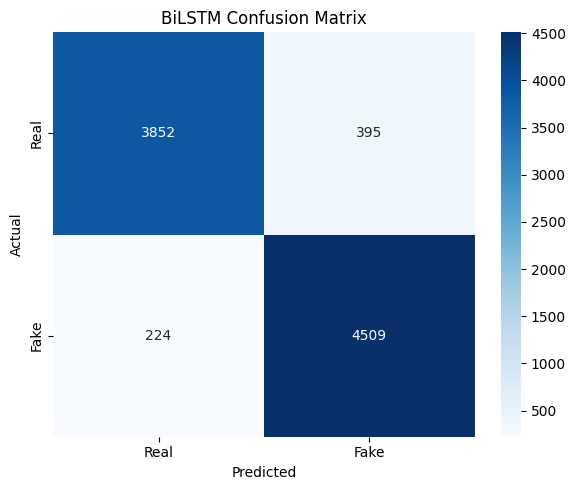

In [11]:
# Predictions
y_pred_prob = bilstm_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
print("===== BiLSTM Model Performance =====")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=['Real', 'Fake']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('BiLSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [12]:
# Check all layers and their shapes
print("===== Model 1 Layers =====")
for i, layer in enumerate(bilstm_model.layers):
    weights = layer.get_weights()
    if weights:
        print(f"Layer {i}: {layer.name} → weight shape: {weights[0].shape}")
    else:
        print(f"Layer {i}: {layer.name} → no weights")

===== Model 1 Layers =====
Layer 0: input_layer → no weights
Layer 1: embedding → weight shape: (50000, 64)
Layer 2: bidirectional → weight shape: (64, 160)
Layer 3: dropout → no weights
Layer 4: bidirectional_1 → weight shape: (80, 80)
Layer 5: dropout_1 → no weights
Layer 6: dense → weight shape: (40, 17)
Layer 7: dense_1 → weight shape: (17, 1)


In [13]:
import pickle
import numpy as np

# Save tokenizer to Drive
with open(f'{SAVE_PATH}tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved to Drive!")

# Save embedding weights to Drive
# Embedding is Layer 1 — save it correctly
embedding_layer = bilstm_model.layers[1]  # ← Layer 1, not Layer 2!
print(f"Layer name: {embedding_layer.name}")

embedding_weights = embedding_layer.get_weights()[0]
print(f"Embedding shape: {embedding_weights.shape}")
# Should be → (50000, 128)

# Save to Drive
np.save(f'{SAVE_PATH}embedding_weights.npy', embedding_weights)
print("Correct embeddings saved to Drive!")

# Save model to Drive
bilstm_model.save(f'{SAVE_PATH}bilstm_best.h5')
print("Model saved to Drive!")

print("\n Files in Drive:")
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(f'{SAVE_PATH}{f}')
    print(f"├── {f} ({size:,} bytes)")

Tokenizer saved to Drive!
Layer name: embedding
Embedding shape: (50000, 64)


Correct embeddings saved to Drive!
Model saved to Drive!

 Files in Drive:
├── Fake.csv (62,789,876 bytes)
├── True.csv (53,582,940 bytes)
├── tokenizer.pkl (10,703,153 bytes)
├── embedding_weights.npy (12,800,128 bytes)
├── bilstm_best.h5 (13,475,104 bytes)
├── att_bilstm_best.h5 (13,499,928 bytes)
├── att_embedding_weights.npy (12,800,128 bytes)
├── loss_curves.png (48,511 bytes)
├── BiLSTM.ipynb (58,582 bytes)


Test on unseen data

1.
 Step 1 - Clean (same as before)
cleaned = [clean_text(news) for news in news_list]
2.
 Step 2 - Tokenize (same tokenizer from training)
sequences = tokenizer.texts_to_sequences(cleaned)
3.
 Step 3 - Pad (same MAX_LEN=500)
padded = pad_sequences(sequences, maxlen=MAX_LEN)
4.
Step 4 - Predict
predictions = bilstm_model.predict(padded)

In [14]:
#  If restarting Colab, load these first:
# bilstm_model = load_model('bilstm_best.h5')
# with open('tokenizer.pkl', 'rb') as f:
#     tokenizer = pickle.load(f)

def predict_news(news_list):
    # Clean
    cleaned = [clean_text(news) for news in news_list]
    # Tokenize
    sequences = tokenizer.texts_to_sequences(cleaned)
    # Pad
    padded = pad_sequences(sequences, maxlen=MAX_LEN,
                           padding='post', truncating='post')
    # Predict
    predictions = bilstm_model.predict(padded)

    print("===== Unseen Data Predictions =====\n")
    for i, (news, pred) in enumerate(zip(news_list, predictions)):
        label = "FAKE " if pred > 0.5 else "REAL "
        confidence = pred[0] if pred > 0.5 else 1 - pred[0]
        print(f"Article {i+1}: {news[:80]}...")
        print(f"Prediction: {label} | Confidence: {confidence:.2%}\n")

# Test with your own articles! ---> This is from Fake.csv
sample_news = [
    " Gay GOP Operative Endorses Doug Jones Over ‘Bigoted, Deviant’ Roy Moore In Senate Race (VIDEO). The Republican Party has a Roy Moore problem. Even before it came out that the judge turned Alabama Senate candidate is accused of being a child molester, he was a problem. He had been removed twice from the Alabama Supreme Court for flagrantly defying the law. Moore has said Muslims should not be allowed to serve in Congress. He waved a gun around on stage at a campaign rally and rode a horse to the polls in Alabama to vote for himself in the primary he would eventually win against establishment-backed interim Senator Luther Strange. Well, it seems that with all of this and then some, sane Republicans have had enough of Roy Moore. One such person is former Jeb Bush campaign strategist Tim Miller. He  has a solution to his party s Roy Moore problem: Vote for the Democrat, Doug Jones, to keep Roy Moore the hell away from the United States Senate.Miller happens to be gay, so of course Moore s disgusting homophobia is a problem for him. Then there is, of course, the child molesting. In a column for the left-wing site Crooked Media entitled  The Republican Case for Doug Jones,  Miller says of his decision, which he calls,  obvious : But here we are in the dark abyss of 2017, and in this political moment, child exploitation attempted child rape, even has become a partisan issue. President Donald Trump is even cool with it, as long as the sex predator is on his team. A comrade in genital grabbing if you will. So after Trump essentially re-endorsed Alabama s Republican Senate candidate Roy Moore, this particular child predator, on Tuesday, I took what I thought was an obvious step. I donated to the other guy s campaign. But in this instance there was one wrinkle for me. The other guy, Doug Jones, is a Democrat. And I a Republican political operative have never donated to one of those before. Thus, in sharing the fact that I had made the donation on social media, I also noted that this was a first for me, even though it felt extremely obvious. Here is the tweet where Tim Miller announces his crossover:I just donated to a Democrat for the first time in my life if any of yall want to do so as well. Enough is enough. https://t.co/YlDXTXSnyJ  Tim Miller (@Timodc) November 21, 2017Tim Miller is right. Roy Moore is absolutely deplorable, and should be nowhere near the United States Senate. This isn t politics, it s morals. Now, it is time for more sane, reasonable Republicans to get out there and do the unthinkable   reject a child molester and endorse and donate to the man who prosecuted the Ku Klux Klan while Roy Moore was busy creeping on little girls. It s not that hard.Watch the video of Tim Miller s appearance on The Last Word with Lawrence O Donnell below:Featured image via Drew Angerer/Getty Images"
]

predict_news(sample_news)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
===== Unseen Data Predictions =====

Article 1:  Gay GOP Operative Endorses Doug Jones Over ‘Bigoted, Deviant’ Roy Moore In Sena...
Prediction: FAKE  | Confidence: 99.41%



In [15]:
# If restarting Colab, load these first:
# bilstm_model = load_model('bilstm_best.h5')
# with open('tokenizer.pkl', 'rb') as f:
#     tokenizer = pickle.load(f)

def predict_news(news_list):
    # Clean
    cleaned = [clean_text(news) for news in news_list]
    # Tokenize
    sequences = tokenizer.texts_to_sequences(cleaned)
    # Pad
    padded = pad_sequences(sequences, maxlen=MAX_LEN,
                           padding='post', truncating='post')
    # Predict
    predictions = bilstm_model.predict(padded)

    print("===== Unseen Data Predictions =====\n")
    for i, (news, pred) in enumerate(zip(news_list, predictions)):
        label = "FAKE " if pred > 0.5 else "REAL "
        confidence = pred[0] if pred > 0.5 else 1 - pred[0]
        print(f"Article {i+1}: {news[:80]}...")
        print(f"Prediction: {label} | Confidence: {confidence:.2%}\n")

# Test with your own articles! ---> This is from True.csv
sample_news = [
    " U.N. experts urge Aung San Suu Kyi to meet persecuted Rohingya. GENEVA (Reuters) - Myanmar s leader Aung San Suu Kyi should personally meet members of the Muslim Rohingya minority which is being subjected to ongoing persecution by the military, a group of U.N. human rights experts said on Tuesday. Myanmar has rejected U.N. accusations that its forces are engaged in ethnic cleansing against Rohingya Muslims in response to coordinated attacks by Rohingya insurgents on the security forces on Aug. 25.  The military campaign has sent nearly 430,000 refugees fleeing to Bangladesh, the group of seven U.N. officials said. They include the special rapporteurs on human rights in Myanmar, on minority issues and on racism.    We call on Aung San Suu Kyi to meet the Rohingya personally,  the officials said in a statement. They said the implementation of promises by Suu Kyi to address the crisis, including that perpetrators would be held accountable, would amount to an  empty gesture  since so many Rohingya had fled.  Suu Kyi is Nobel Peace prize winner whose government came to power last year in a transition from nearly 50 years of harsh military rule. She has denounced any rights violations but international pressure on her is mounting and there are calls for her Nobel prize to be withdrawn. Suu Kyi has little if any control over the security forces under a military-drafted constitution that also bars her from the presidency and gives the military veto power over political reform. The 1.1 million Rohingya in Buddhist majority Myanmar are denied citizenship and classified as illegal immigrants from Bangladesh, despite claiming roots in the region that go back centuries, with communities marginalized and occasionally subjected to communal violence."
]

predict_news(sample_news)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
===== Unseen Data Predictions =====

Article 1:  U.N. experts urge Aung San Suu Kyi to meet persecuted Rohingya. GENEVA (Reuters...
Prediction: REAL  | Confidence: 97.78%



Training Data Distribution:
└── 2016-2017 US political news
    └── Real news = Reuters formal style
    └── Fake news = sensational political claims

Your Test Article Distribution:
└── 2025-2026 geopolitical news
    └── Different vocabulary
    └── Different political context
    └── Model has never seen this pattern before

1. IF article contains "Trump" + "Clinton" + "election"
THEN → very likely FAKE (regardless of style)

2. his BiLSTM is good at:
  Detecting fake news within its training distribution
  Topics it has seen patterns for
  Clear stylistic differences
  
3. This BiLSTM is bad at:
  Topics heavily covered in both fake AND real news
  News outside its training period
  Distinguishing topic from style

###Model 2 ---> BiLSTM with attention mechanism

In [16]:
# ================================================================
#  MODEL 2 — Attention-Based BiLSTM
# ================================================================
print("=" * 60)
print("       MODEL 2 — Attention-Based BiLSTM")
print("=" * 60)

       MODEL 2 — Attention-Based BiLSTM


In [17]:
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

In [18]:
# Model 2 uses same SAVE_PATH as Model 1
ATT_MAX_LEN    = 500
ATT_MAX_VOCAB  = 50000
ATT_EMBED_DIM  = 64
ATT_LSTM_UNITS = 20
ATT_DENSE_UNITS = 15
ATT_LEARNING_RATE = 0.0001         # ← add this!

print("===== Model 2 Hyperparameters =====")
print(f"MAX_LEN:     {ATT_MAX_LEN}")
print(f"MAX_VOCAB:   {ATT_MAX_VOCAB}")
print(f"EMBED_DIM:   {ATT_EMBED_DIM}")
print(f"LSTM_UNITS:  {ATT_LSTM_UNITS}")
print(f"DENSE_UNITS: {ATT_DENSE_UNITS}")

===== Model 2 Hyperparameters =====
MAX_LEN:     500
MAX_VOCAB:   50000
EMBED_DIM:   64
LSTM_UNITS:  20
DENSE_UNITS: 15


In [19]:
# Load tokenizer from Drive (saved by Model 1)
with open(f'{SAVE_PATH}tokenizer.pkl', 'rb') as f:
    att_tokenizer = pickle.load(f)
print("Tokenizer loaded from Drive!")

# Load pretrained embeddings from Drive (saved by Model 1)
att_embedding_weights = np.load(f'{SAVE_PATH}embedding_weights.npy')
print(f" Embeddings loaded! Shape: {att_embedding_weights.shape}")

Tokenizer loaded from Drive!
 Embeddings loaded! Shape: (50000, 64)


In [20]:
# Reuse df already in memory from Model 1
# Just re-pad with ATT_MAX_LEN=500
att_sequences = att_tokenizer.texts_to_sequences(df['content'])

X2 = pad_sequences(att_sequences,
                   maxlen=ATT_MAX_LEN,
                   padding='post',
                   truncating='post')
y2 = df['label'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print("===== Model 2 Data =====")
print(f"X2_train shape: {X2_train.shape}")
print(f"X2_test shape:  {X2_test.shape}")

===== Model 2 Data =====
X2_train shape: (35918, 500)
X2_test shape:  (8980, 500)


In [21]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # W matrix
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='random_normal',
            trainable=True
        )
        # b bias
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        # u context vector
        self.u = self.add_weight(
            name='attention_context',
            shape=(input_shape[-1],),
            initializer='random_normal',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Step 1: Score → e_t = tanh(W · h_t + b)
        e = K.tanh(K.dot(x, self.W) + self.b)

        # Step 1b: Collapse → e_t = u · tanh(...)
        e = K.dot(e, K.expand_dims(self.u))
        e = K.squeeze(e, axis=-1)

        # Step 2: Normalize → softmax
        alpha = K.softmax(e)

        # Step 3: Weighted sum → context = Σ α_t × h_t
        alpha = K.expand_dims(alpha, axis=-1)
        context = K.sum(x * alpha, axis=1)

        return context

print("Attention Layer defined!")

Attention Layer defined!


In [22]:
def build_attention_bilstm():
    inputs = Input(shape=(ATT_MAX_LEN,))

    x = Embedding(
        input_dim=ATT_MAX_VOCAB,
        output_dim=ATT_EMBED_DIM,
        weights=[att_embedding_weights],
        trainable=False                # ← freeze embedding!
    )(inputs)

    x = Bidirectional(LSTM(ATT_LSTM_UNITS * 2,
                           return_sequences=True))(x)
    x = Dropout(0.5)(x)

    x = Bidirectional(LSTM(ATT_LSTM_UNITS,
                           return_sequences=True))(x)
    x = Dropout(0.5)(x)

    x = AttentionLayer()(x)

    x = Dense(ATT_DENSE_UNITS, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

att_bilstm_model = build_attention_bilstm()

att_bilstm_model.compile(
    optimizer=Adam(learning_rate=ATT_LEARNING_RATE),  # ← slower lr!
    loss='binary_crossentropy',
    metrics=['accuracy']
)

att_bilstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 500, 64)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 500, 80)        │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 500, 40)        │        16,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 40)             │         1,680 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           615 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,252,071 (12.41 MB)

 Trainable params: 52,071 (203.40 KB)

 Non-trainable params: 3,200,000 (12.21 MB)

In [23]:
att_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,                        # ← patience=2 for Model 2
    restore_best_weights=True          # (needs more epochs to converge)
)

att_checkpoint = ModelCheckpoint(
    f'{SAVE_PATH}att_bilstm_best.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

att_reduce_lr = ReduceLROnPlateau(     # ← NEW callback!
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=0.000001,
    verbose=1
)

history_att = att_bilstm_model.fit(
    X2_train, y2_train,
    epochs=10,                         # ← increase epochs
    batch_size=64,
    validation_split=0.1,
    callbacks=[att_early_stop, att_checkpoint, att_reduce_lr],  # ← add!
    verbose=1
)

Epoch 1/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5539 - loss: 0.6834
Epoch 1: val_loss improved from None to 0.49733, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.6098 - loss: 0.6479 - val_accuracy: 0.7731 - val_loss: 0.4973 - learning_rate: 1.0000e-04
Epoch 2/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7455 - loss: 0.5422
Epoch 2: val_loss improved from 0.49733 to 0.39098, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.7782 - loss: 0.4875 - val_accuracy: 0.8246 - val_loss: 0.3910 - learning_rate: 1.0000e-04
Epoch 3/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8596 - loss: 0.3426
Epoch 3: val_loss improved from 0.39098 to 0.25738, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.8735 - loss: 0.3151 - val_accuracy: 0.9012 - val_loss: 0.2574 - learning_rate: 1.0000e-04
Epoch 4/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9083 - loss: 0.2380
Epoch 4: val_loss improved from 0.25738 to 0.20541, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.9102 - loss: 0.2294 - val_accuracy: 0.9126 - val_loss: 0.2054 - learning_rate: 1.0000e-04
Epoch 5/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9197 - loss: 0.2020
Epoch 5: val_loss did not improve from 0.20541

Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.9241 - loss: 0.1946 - val_accuracy: 0.9106 - val_loss: 0.2165 - learning_rate: 1.0000e-04
Epoch 6/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9333 - loss: 0.1759
Epoch 6: val_loss improved from 0.20541 to 0.16723, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 34s 66ms/step - accuracy: 0.9322 - loss: 0.1764 - val_accuracy: 0.9329 - val_loss: 0.1672 - learning_rate: 5.0000e-05
Epoch 7/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9292 - loss: 0.1784
Epoch 7: val_loss improved from 0.16723 to 0.16394, saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Project_DL_BiLSTM/att_bilstm_best.h5
506/506 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.9327 - loss: 0.1730 - val_accuracy: 0.9376 - val_loss: 0.1639 - learning_rate: 5.0000e-05
Epoch 8/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9353 - loss: 0.1659
Epoch 8: val_loss did not improve from 0.16394

Epoch 8: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9363 - loss: 0.1628 - val_accuracy: 0.9312 - val_loss: 0.1713 - learning_rate: 5.0000e-05
Epoch 9/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9399 - loss: 0.1551
Epoch 9: val_loss did not improve from 0.16394

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.9401 - loss: 0.1566 - val_accuracy: 0.9285 - val_loss: 0.1794 - learning_rate: 2.5000e-05


281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step
===== Attention-BiLSTM Model Performance =====
Accuracy:  0.9374
Precision: 0.9486
Recall:    0.9318
F1-Score:  0.9401

Classification Report:

              precision    recall  f1-score   support

        Real       0.93      0.94      0.93      4247
        Fake       0.95      0.93      0.94      4733

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



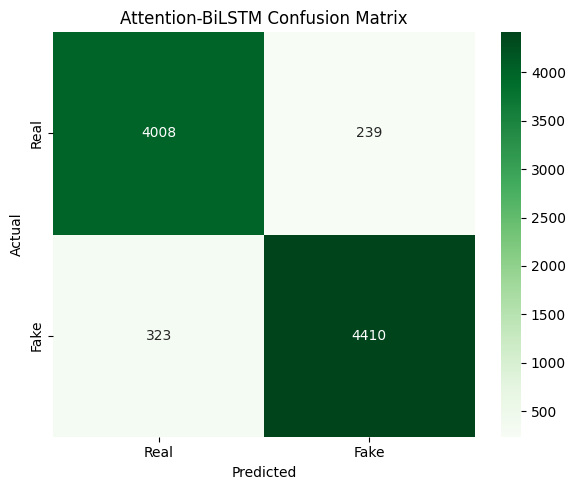

In [24]:
y2_pred_prob = att_bilstm_model.predict(X2_test)
y2_pred = (y2_pred_prob > 0.5).astype(int)

print("===== Attention-BiLSTM Model Performance =====")
print(f"Accuracy:  {accuracy_score(y2_test, y2_pred):.4f}")
print(f"Precision: {precision_score(y2_test, y2_pred):.4f}")
print(f"Recall:    {recall_score(y2_test, y2_pred):.4f}")
print(f"F1-Score:  {f1_score(y2_test, y2_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y2_test, y2_pred,
                            target_names=['Real', 'Fake']))

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Attention-BiLSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [25]:
att_emb_layer = None
for layer in att_bilstm_model.layers:
    if 'embedding' in layer.name:
        att_emb_layer = layer
        break

att_emb_weights = att_emb_layer.get_weights()[0]
np.save(f'{SAVE_PATH}att_embedding_weights.npy', att_emb_weights)
print(f"Model 2 embeddings saved! Shape: {att_emb_weights.shape}")

print("\n All files in Drive:")
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(f'{SAVE_PATH}{f}')
    print(f"├── {f} ({size:,} bytes)")

Model 2 embeddings saved! Shape: (50000, 64)

 All files in Drive:
├── Fake.csv (62,789,876 bytes)
├── True.csv (53,582,940 bytes)
├── tokenizer.pkl (10,703,153 bytes)
├── embedding_weights.npy (12,800,128 bytes)
├── bilstm_best.h5 (13,475,104 bytes)
├── att_bilstm_best.h5 (13,499,928 bytes)
├── att_embedding_weights.npy (12,800,128 bytes)
├── loss_curves.png (48,511 bytes)
├── BiLSTM.ipynb (118,154 bytes)


In [26]:
def predict_news_att(news_list):
    cleaned = [clean_text(news) for news in news_list]
    sequences = att_tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(sequences, maxlen=ATT_MAX_LEN,
                           padding='post', truncating='post')
    predictions = att_bilstm_model.predict(padded)

    print("===== Model 2 (Attention-BiLSTM) Predictions =====\n")
    for i, (news, pred) in enumerate(zip(news_list, predictions)):
        label = "FAKE " if pred > 0.5 else "REAL "
        confidence = pred[0] if pred > 0.5 else 1 - pred[0]
        print(f"Article {i+1}: {news[:80]}...")
        print(f"Prediction: {label} | Confidence: {confidence:.2%}\n")

# Test same articles as Model 1 for comparison! --> from fake.csv
sample_news = [
    " Gay GOP Operative Endorses Doug Jones Over ‘Bigoted, Deviant’ Roy Moore In Senate Race (VIDEO). The Republican Party has a Roy Moore problem. Even before it came out that the judge turned Alabama Senate candidate is accused of being a child molester, he was a problem. He had been removed twice from the Alabama Supreme Court for flagrantly defying the law. Moore has said Muslims should not be allowed to serve in Congress. He waved a gun around on stage at a campaign rally and rode a horse to the polls in Alabama to vote for himself in the primary he would eventually win against establishment-backed interim Senator Luther Strange. Well, it seems that with all of this and then some, sane Republicans have had enough of Roy Moore. One such person is former Jeb Bush campaign strategist Tim Miller. He  has a solution to his party s Roy Moore problem: Vote for the Democrat, Doug Jones, to keep Roy Moore the hell away from the United States Senate.Miller happens to be gay, so of course Moore s disgusting homophobia is a problem for him. Then there is, of course, the child molesting. In a column for the left-wing site Crooked Media entitled  The Republican Case for Doug Jones,  Miller says of his decision, which he calls,  obvious : But here we are in the dark abyss of 2017, and in this political moment, child exploitation attempted child rape, even has become a partisan issue. President Donald Trump is even cool with it, as long as the sex predator is on his team. A comrade in genital grabbing if you will. So after Trump essentially re-endorsed Alabama s Republican Senate candidate Roy Moore, this particular child predator, on Tuesday, I took what I thought was an obvious step. I donated to the other guy s campaign. But in this instance there was one wrinkle for me. The other guy, Doug Jones, is a Democrat. And I a Republican political operative have never donated to one of those before. Thus, in sharing the fact that I had made the donation on social media, I also noted that this was a first for me, even though it felt extremely obvious. Here is the tweet where Tim Miller announces his crossover:I just donated to a Democrat for the first time in my life if any of yall want to do so as well. Enough is enough. https://t.co/YlDXTXSnyJ  Tim Miller (@Timodc) November 21, 2017Tim Miller is right. Roy Moore is absolutely deplorable, and should be nowhere near the United States Senate. This isn t politics, it s morals. Now, it is time for more sane, reasonable Republicans to get out there and do the unthinkable   reject a child molester and endorse and donate to the man who prosecuted the Ku Klux Klan while Roy Moore was busy creeping on little girls. It s not that hard.Watch the video of Tim Miller s appearance on The Last Word with Lawrence O Donnell below:Featured image via Drew Angerer/Getty Images"

]

predict_news_att(sample_news)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
===== Model 2 (Attention-BiLSTM) Predictions =====

Article 1:  Gay GOP Operative Endorses Doug Jones Over ‘Bigoted, Deviant’ Roy Moore In Sena...
Prediction: FAKE  | Confidence: 99.10%



In [27]:
def predict_news_att(news_list):
    cleaned = [clean_text(news) for news in news_list]
    sequences = att_tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(sequences, maxlen=ATT_MAX_LEN,
                           padding='post', truncating='post')
    predictions = att_bilstm_model.predict(padded)

    print("===== Model 2 (Attention-BiLSTM) Predictions =====\n")
    for i, (news, pred) in enumerate(zip(news_list, predictions)):
        label = "FAKE " if pred > 0.5 else "REAL "
        confidence = pred[0] if pred > 0.5 else 1 - pred[0]
        print(f"Article {i+1}: {news[:80]}...")
        print(f"Prediction: {label} | Confidence: {confidence:.2%}\n")

# Test same articles as Model 1 for comparison --> from true.csv
sample_news = [
    " U.N. experts urge Aung San Suu Kyi to meet persecuted Rohingya. GENEVA (Reuters) - Myanmar s leader Aung San Suu Kyi should personally meet members of the Muslim Rohingya minority which is being subjected to ongoing persecution by the military, a group of U.N. human rights experts said on Tuesday. Myanmar has rejected U.N. accusations that its forces are engaged in ethnic cleansing against Rohingya Muslims in response to coordinated attacks by Rohingya insurgents on the security forces on Aug. 25.  The military campaign has sent nearly 430,000 refugees fleeing to Bangladesh, the group of seven U.N. officials said. They include the special rapporteurs on human rights in Myanmar, on minority issues and on racism.    We call on Aung San Suu Kyi to meet the Rohingya personally,  the officials said in a statement. They said the implementation of promises by Suu Kyi to address the crisis, including that perpetrators would be held accountable, would amount to an  empty gesture  since so many Rohingya had fled.  Suu Kyi is Nobel Peace prize winner whose government came to power last year in a transition from nearly 50 years of harsh military rule. She has denounced any rights violations but international pressure on her is mounting and there are calls for her Nobel prize to be withdrawn. Suu Kyi has little if any control over the security forces under a military-drafted constitution that also bars her from the presidency and gives the military veto power over political reform. The 1.1 million Rohingya in Buddhist majority Myanmar are denied citizenship and classified as illegal immigrants from Bangladesh, despite claiming roots in the region that go back centuries, with communities marginalized and occasionally subjected to communal violence."

]

predict_news_att(sample_news)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
===== Model 2 (Attention-BiLSTM) Predictions =====

Article 1:  U.N. experts urge Aung San Suu Kyi to meet persecuted Rohingya. GENEVA (Reuters...
Prediction: REAL  | Confidence: 97.96%

